## Práctica 2: Procesamiento básico de imágenes con OpenCV y Python
### Autor: Juan Manuel Mena Hernandez
### Fecha: 24-02-2026


### EJERCICIO 1. CARGAR IMAGENES, OBTENER INFORMACÍON, ROTAR Y MOSTRAR AMBAS IMÁGENES
Escriba un programa en Python que use dos variables nombreA y nombreB. 
En nombreA guardaremos el nombre de la imagen que se va a cargar y en nombreB estará el nombre de la imagen resultante de la transformación que haremos. Calcular las dimensiones de la imagen original (alto, ancho y bandas) y mostrarlas. 
En el nombreB guardaremos una versión de la misma rotada 90º, en sentido horario. Dicha rotación se llevará a cabo creando una imagen nueva y copiando los píxeles desde la imagen original (nombreA) en las posiciones adecuadas.
Por último, mostraremos ambas imágenes por pantalla para poder ver la diferencia.


Dimensiones de la imagen original:
- Alto: 900
- Ancho: 1200
- Bandas: 3


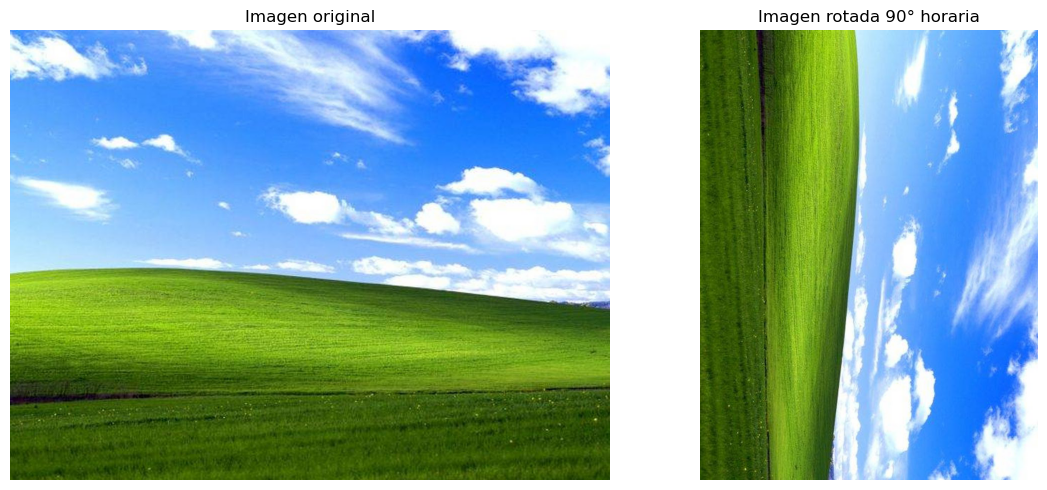

Imagen rotada guardada como: imagen_rotada_90_horaria.jpg


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Nombres de archivo
nombreA = "imagen.jpg"
nombreB = "imagen_rotada_90_horaria.jpg"

# 1) Cargar imagen
imagen = cv2.imread(nombreA, cv2.IMREAD_UNCHANGED)
if imagen is None:
    raise FileNotFoundError(f"No se pudo cargar la imagen: {nombreA}")

# 2) Obtener dimensiones (alto, ancho, bandas)
alto, ancho = imagen.shape[:2]
bandas = 1 if imagen.ndim == 2 else imagen.shape[2]
print(f"Dimensiones de la imagen original:")
print(f"- Alto: {alto}")
print(f"- Ancho: {ancho}")
print(f"- Bandas: {bandas}")

# 3) Rotar 90º en sentido horario creando imagen nueva y copiando píxeles
# cv2.rotate(imagen, cv2.ROTATE_90_CLOCKWISE) también podría usarse para rotar sin necesidad de copiar píxeles manualmente
if imagen.ndim == 2: # Si es escala de grises, la imagen rotada también será 2D
    rotada = np.zeros((ancho, alto), dtype=imagen.dtype)
    for i in range(alto):
        for j in range(ancho):
            rotada[j, alto - 1 - i] = imagen[i, j]
else: # Si es a color, la imagen rotada también tendrá 3 canales
    rotada = np.zeros((ancho, alto, bandas), dtype=imagen.dtype)
    for i in range(alto):
        for j in range(ancho):
            rotada[j, alto - 1 - i, :] = imagen[i, j, :]

# 4) Guardar imagen rotada
ok = cv2.imwrite(nombreB, rotada)
if not ok:
    raise IOError(f"No se pudo guardar la imagen rotada en: {nombreB}")

# 5) Mostrar ambas imágenes
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
if imagen.ndim == 2: # Si es escala de grises, usar cmap="gray"
    plt.imshow(imagen, cmap="gray")
else: # Si es a color, convertir de BGR a RGB para mostrar correctamente con matplotlib
    plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 2, 2)
if rotada.ndim == 2: # Si es escala de grises, usar cmap="gray"
    plt.imshow(rotada, cmap="gray")
else: # Si es a color, convertir de BGR a RGB para mostrar correctamente con matplotlib
    plt.imshow(cv2.cvtColor(rotada, cv2.COLOR_BGR2RGB))
plt.title("Imagen rotada 90° horaria")
plt.axis("off")

plt.tight_layout()
plt.show()

print(f"Imagen rotada guardada como: {nombreB}")

El código usa una imagen y la rota 90 grados en sentido horario redibujándola píxel por píxel.

Primero, carga el archivo y crea un nuevo lienzo vacío donde intercambia el alto por el ancho. Luego, recorre cada punto de la imagen original y calcula su nueva posición mediante una fórmula matemática (j, alto - 1 - i), moviendo manualmente cada color a su lugar correspondiente en la nueva cuadrícula.

Finalmente, el script corrige el formato de color (de BGR a RGB) para que los tonos se vean naturales al mostrarse en pantalla. Tras procesar la información, guarda el resultado en un nuevo archivo JPG y genera una comparativa visual de "antes y después" para que puedas verificar el giro.

### EJERCICIO 2. CARGAR IMAGENES, INVERTIR COLORES (NEGATIVO) Y GUARDAR
Escriba un programa en Python que use dos variables nombreA y nombreB. 
En nombreA tendremos la imagen original y en nombreB guardaremos el resultado. El objetivo es crear el "negativo" de la foto. Para ello, debe crear una imagen nueva de las mismas dimensiones que la original. Recorriendo la imagen original píxel a píxel, debe calcular el valor inverso para cada canal de color (el nuevo valor será 255 - valor original). Por último, muestre ambas imágenes
en pantalla y guarde el resultado en el archivo especificado en nombreB.


Dimensiones de la imagen original:
- Alto: 900
- Ancho: 1200
- Bandas: 3


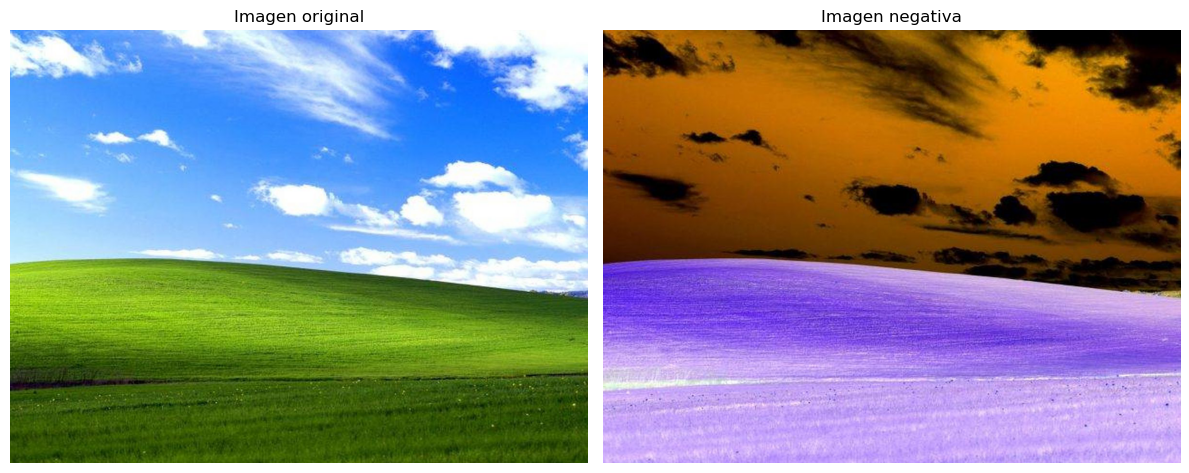

Imagen negativa guardada como: imagen_negativo.jpg


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Nombres de archivo
nombreA = "imagen.jpg"
nombreB = "imagen_negativo.jpg"

# 1) Cargar imagen
imagen = cv2.imread(nombreA, cv2.IMREAD_UNCHANGED)
if imagen is None:
    raise FileNotFoundError(f"No se pudo cargar la imagen: {nombreA}")

# 2) Obtener dimensiones (alto, ancho, bandas)
alto, ancho = imagen.shape[:2]
bandas = 1 if imagen.ndim == 2 else imagen.shape[2]
print(f"Dimensiones de la imagen original:")
print(f"- Alto: {alto}")
print(f"- Ancho: {ancho}")
print(f"- Bandas: {bandas}")

# 3) Crear imagen negativa
# imagen - 255 también podría usarse para crear el negativo sin necesidad de copiar píxeles manualmente
# cv2.bitwise_not(imagen) también podría usarse para crear el negativo de manera eficiente sin necesidad de copiar píxeles manualmente
negativo = np.zeros_like(imagen) # Creo una matriz vacía con las mismas dimensiones y tipo de datos que la imagen original
if imagen.ndim == 2: # Si la imagen es en escala de grises
    for i in range(alto):
        for j in range(ancho):
            negativo[i, j] = 255 - imagen[i, j]
else: # Si la imagen es a color (BGR)
    for i in range(alto):
        for j in range(ancho):
            for k in range(bandas):
                negativo[i, j, k] = 255 - imagen[i, j, k]

# 4) Guardar imagen negativa
ok = cv2.imwrite(nombreB, negativo)
if not ok:
    raise IOError(f"No se pudo guardar la imagen negativa en: {nombreB}")

# 5) Mostrar ambas imágenes
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
if imagen.ndim == 2: # Si es escala de grises, usar cmap="gray"
    plt.imshow(imagen, cmap="gray") 
else: 
    plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 2, 2)
if negativo.ndim == 2: # Si es escala de grises, usar cmap="gray"
    plt.imshow(negativo, cmap="gray")
else: # Si es a color, convertir de BGR a RGB para mostrar correctamente con matplotlib
    plt.imshow(cv2.cvtColor(negativo, cv2.COLOR_BGR2RGB))
plt.title("Imagen negativa")
plt.axis("off")

plt.tight_layout()
plt.show()

print(f"Imagen negativa guardada como: {nombreB}")

Este código transforma una imagen original en su versión negativa invirtiendo los colores de forma manual. 

Básicamente, recorre cada píxel y resta su valor actual al máximo posible (255), lo que hace que los tonos claros se vuelvan oscuros y los oscuros se vuelven claros, tal como sucedía con los antiguos carretes de fotos.Para lograrlo, el script crea una matriz vacía con las mismas dimensiones que la original y aplica la operación (255 - valor del píxel) en cada canal de color (Rojo, Verde y Azul).
 
Al finalizar, el código corrige el orden de los colores para que se vean bien en pantalla (pasando de BGR a RGB), guarda el resultado en un nuevo archivo y muestra una comparativa visual de la imagen normal frente a su negativo.

### EJERCICIO 3. CARGAR IMAGENES, OBTENER INFORMACIÓN, REFLEJAR Y MOSTRAR AMBAS IMAGENES
Siguiendo con lo escrito en el anterior ejercicio, ahora se pide realizar una versión de la misma reflejada en el eje vertical. Dicha versión reflejada se llevará a cabo creando una imagen nueva y copiando los píxeles desde la imagen original en las posiciones adecuadas

Dimensiones de la imagen original:
- Alto: 900
- Ancho: 1200
- Bandas: 3


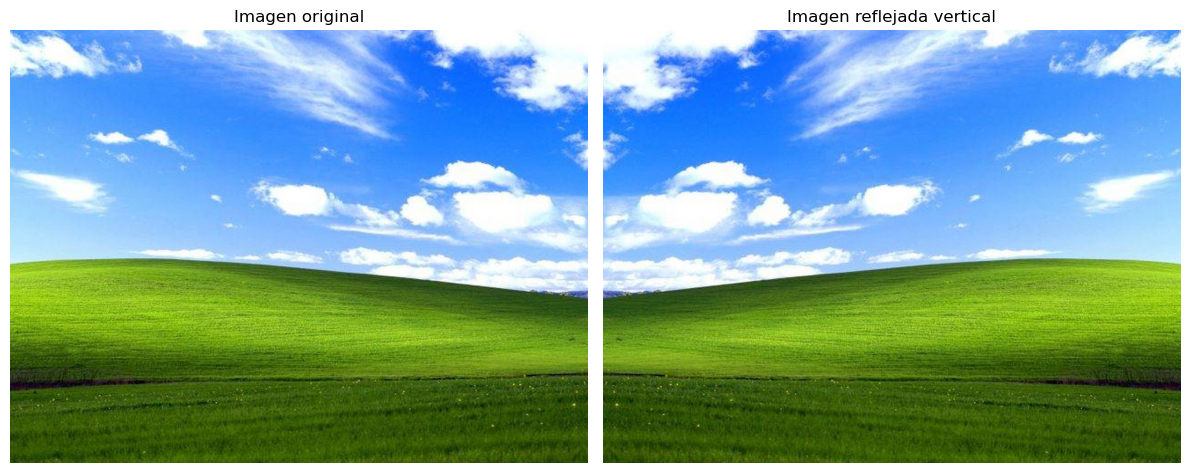

Imagen reflejada guardada como: imagen_reflejada_vertical.jpg


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Nombres de archivo
nombreA = "imagen.jpg"
nombreB = "imagen_reflejada_vertical.jpg"

# 1) Cargar imagen
imagen = cv2.imread(nombreA, cv2.IMREAD_UNCHANGED)
if imagen is None:
    raise FileNotFoundError(f"No se pudo cargar la imagen: {nombreA}")

# 2) Obtener dimensiones (alto, ancho, bandas)
alto, ancho = imagen.shape[:2]
bandas = 1 if imagen.ndim == 2 else imagen.shape[2]
print(f"Dimensiones de la imagen original:")
print(f"- Alto: {alto}")
print(f"- Ancho: {ancho}")
print(f"- Bandas: {bandas}")

# 3) Reflejar en el eje vertical (crear imagen nueva y copiar píxeles)
# cv2.flip(imagen, 1) también podría usarse para reflejar sin necesidad de copiar píxeles manualmente
if imagen.ndim == 2:  # Escala de grises
    reflejada = np.zeros_like(imagen)
    for i in range(alto):
        for j in range(ancho):
            reflejada[i, ancho - 1 - j] = imagen[i, j]
else:  # Color
    reflejada = np.zeros_like(imagen)
    for i in range(alto):
        for j in range(ancho):
            reflejada[i, ancho - 1 - j, :] = imagen[i, j, :]

# 4) Guardar imagen reflejada
ok = cv2.imwrite(nombreB, reflejada)
if not ok:
    raise IOError(f"No se pudo guardar la imagen reflejada en: {nombreB}")

# 5) Mostrar ambas imágenes
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
if imagen.ndim == 2:
    plt.imshow(imagen, cmap="gray")
else:
    plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 2, 2)
if reflejada.ndim == 2:
    plt.imshow(reflejada, cmap="gray")
else:
    plt.imshow(cv2.cvtColor(reflejada, cv2.COLOR_BGR2RGB))
plt.title("Imagen reflejada vertical")
plt.axis("off")

plt.tight_layout()
plt.show()

print(f"Imagen reflejada guardada como: {nombreB}")

Este código crea un efecto de espejo (reflejo horizontal) en la imagen, invirtiendo la posición de los píxeles de izquierda a derecha. 

Aunque existe la función cv2.flip para hacerlo automáticamente, este script lo realiza de forma manual recorriendo cada fila y moviendo los píxeles de la columna j a la posición (ancho - 1 - j).

El proceso comienza cargando la imagen y creando una matriz vacía con las mismas dimensiones. Luego, mediante bucles anidados, el código "da la vuelta" a la fotografía manteniendo la altura original pero invirtiendo el orden de las columnas. 

Finalmente, convierte los colores de BGR a RGB para que se vean correctamente en la comparativa visual y guarda el resultado como un nuevo archivo.

### EJERCICIO 4. CARGAR IMAGENES, REALIZAR UN SUBMUESTREO (REDUCIR A LA MITAD) Y MOSTRAR
Siguiendo la lógica de manipulación de coordenadas, escriba un programa que use la variable
nombreA para cargar una imagen. 
El programa debe calcular las dimensiones de la imagen original y crear una nueva imagen vacía que tenga exactamente la mitad de ancho y la mitad de alto que la original. El llenado de esta nueva imagen se hará copiando los píxeles de la imagen original, pero saltando de 2 en 2 (es decir, tomando solo los píxeles de las filas y columnas pares).
Muestre por consola las dimensiones de ambas imágenes para verificar la reducción y visualice
ambas ventanas.

Dimensiones de la imagen original:
- Alto: 900
- Ancho: 1200
- Bandas: 3
Dimensiones de la imagen submuestreada:
- Alto: 450
- Ancho: 600
- Bandas: 3


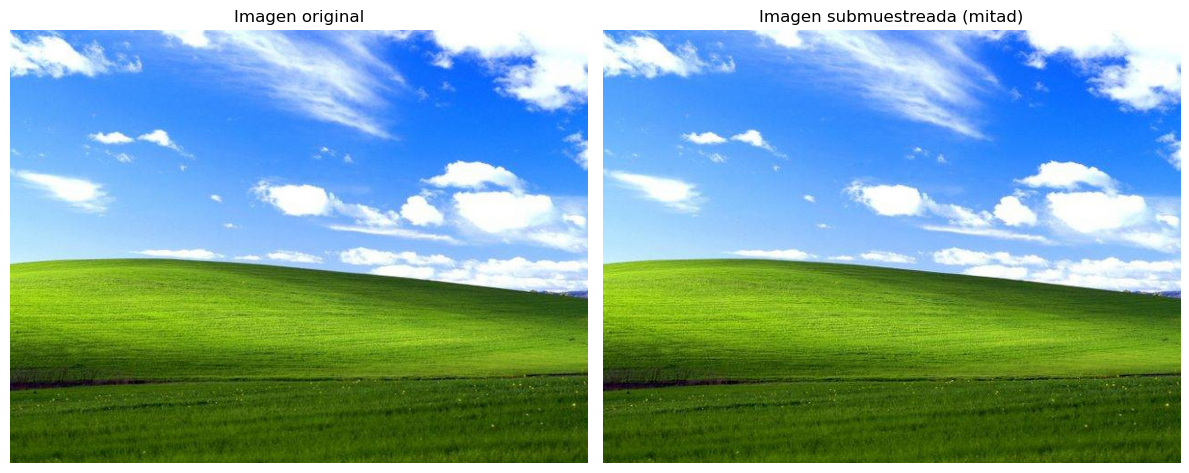

Imagen submuestreada guardada como: imagen_submuestreada.jpg


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Nombres de archivo
nombreA = "imagen.jpg"
nombreB = "imagen_submuestreada.jpg"

# 1) Cargar imagen
imagen = cv2.imread(nombreA, cv2.IMREAD_UNCHANGED)
if imagen is None:
    raise FileNotFoundError(f"No se pudo cargar la imagen: {nombreA}")

# 2) Dimensiones originales
alto, ancho = imagen.shape[:2]
bandas = 1 if imagen.ndim == 2 else imagen.shape[2]
print(f"Dimensiones de la imagen original:")
print(f"- Alto: {alto}")
print(f"- Ancho: {ancho}")
print(f"- Bandas: {bandas}")

# 3) Crear imagen submuestreada (la mitad de alto y ancho)
# cv2.resize(imagen, (ancho//2, alto//2), interpolation=cv2.INTER_NEAREST) también podría usarse para submuestrear sin necesidad de copiar píxeles manualmente
nuevo_alto = alto // 2
nuevo_ancho = ancho // 2
if imagen.ndim == 2:
    subm = np.zeros((nuevo_alto, nuevo_ancho), dtype=imagen.dtype)
    for i in range(nuevo_alto):
        for j in range(nuevo_ancho):
            subm[i, j] = imagen[i*2, j*2]
else:
    subm = np.zeros((nuevo_alto, nuevo_ancho, bandas), dtype=imagen.dtype)
    for i in range(nuevo_alto):
        for j in range(nuevo_ancho):
            subm[i, j, :] = imagen[i*2, j*2, :]

print(f"Dimensiones de la imagen submuestreada:")
print(f"- Alto: {nuevo_alto}")
print(f"- Ancho: {nuevo_ancho}")
print(f"- Bandas: {bandas}")

# 4) Guardar imagen submuestreada
ok = cv2.imwrite(nombreB, subm)
if not ok:
    raise IOError(f"No se pudo guardar la imagen submuestreada en: {nombreB}")

# 5) Mostrar ambas imágenes
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
if imagen.ndim == 2:
    plt.imshow(imagen, cmap="gray")
else:
    plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 2, 2)
if subm.ndim == 2:
    plt.imshow(subm, cmap="gray")
else:
    plt.imshow(cv2.cvtColor(subm, cv2.COLOR_BGR2RGB))
plt.title("Imagen submuestreada (mitad)")
plt.axis("off")

plt.tight_layout()
plt.show()

print(f"Imagen submuestreada guardada como: {nombreB}")

Este código realiza un submuestreo, que consiste en reducir el tamaño de la imagen a la mitad. Para lograrlo de forma manual, el script recorre la imagen original y "salta" píxeles, seleccionando únicamente uno de cada dos (los que están en posiciones pares, como 2, 4, 6...), lo que genera una versión más pequeña y ligera del archivo original.

El proceso comienza calculando las nuevas dimensiones (la mitad del alto y del ancho) y preparando un lienzo vacío con ese tamaño. 

Mediante bucles, el código copia los valores de los píxeles de la imagen original multiplicando los índices por dos (i x 2, j x 2), descartando efectivamente el 75% de la información original. 

Finalmente, guarda la imagen reducida y muestra la comparativa, donde la imagen submuestreada se verá igual pero con una resolución menor.

### EJERCICIO 5. CARGAR IMAGENES Y CREAR IMAGEN RGB
Escriba un programa en Python que, usando la biblioteca OpenCV, que use tres variables ancho alto y nombre y cree una imagen RGB de X píxeles de ancho por Y píxeles de alto.
Seguidamente, dibuje en ella al menos dos l´ıneas, dos polilíneas, dos circunferencias y dos círculos.
Por último, muestre el resultado y lo grabe todo en una imagen png de nombre que esté en la
variable nombre.

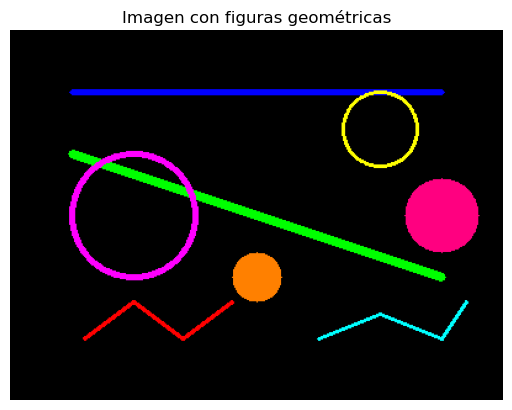

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Variables de dimensiones y nombre de archivo
ancho = 400
alto = 300
nombre = "imagen_dibujo.png"

# 1) Crear una imagen RGB en blanco (fondo negro)
imagen = np.zeros((alto, ancho, 3), dtype=np.uint8)

# 2) Dibujar dos líneas
cv2.line(imagen, (50, 50), (350, 50), (255, 0, 0), 3)      # Línea azul horizontal
cv2.line(imagen, (50, 100), (350, 200), (0, 255, 0), 5)    # Línea verde diagonal

# 3) Dibujar dos polilíneas
pts1 = np.array([[60, 250], [100, 220], [140, 250], [180, 220]], np.int32)
pts1 = pts1.reshape((-1, 1, 2))
cv2.polylines(imagen, [pts1], False, (0, 0, 255), 2)       # Polilínea roja

pts2 = np.array([[250, 250], [300, 230], [350, 250], [370, 220]], np.int32)
pts2 = pts2.reshape((-1, 1, 2))
cv2.polylines(imagen, [pts2], False, (255, 255, 0), 2)     # Polilínea celeste

# 4) Dibujar dos circunferencias (solo borde)
cv2.circle(imagen, (100, 150), 50, (255, 0, 255), 4)       # Circunferencia magenta
cv2.circle(imagen, (300, 80), 30, (0, 255, 255), 2)        # Circunferencia amarilla

# 5) Dibujar dos círculos rellenos
cv2.circle(imagen, (200, 200), 20, (0, 128, 255), -1)      # Círculo naranja
cv2.circle(imagen, (350, 150), 30, (128, 0, 255), -1)      # Círculo violeta

# 6) Guardar la imagen
cv2.imwrite(nombre, imagen)

# 7) Mostrar la imagen con matplotlib (convertir de BGR a RGB)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title("Imagen con figuras geométricas")
plt.axis("off")
plt.show()

Este código genera una imagen desde cero (un lienzo negro de 400x300 píxeles) y utiliza las funciones de dibujo de OpenCV para trazar diversas figuras geométricas. Es una excelente demostración de cómo funcionan las coordenadas y los colores en un espacio digital.

El script comienza creando una matriz de ceros con np.zeros y luego "pinta" sobre ella siguiendo este orden:

* Líneas: Traza una azul horizontal y una verde diagonal definiendo sus puntos de inicio y fin.

* Polilíneas: Crea formas conectando varios puntos (rojo y celeste) sin cerrar el trazo.

* Círculos: Dibuja circunferencias vacías y círculos rellenos (usando el valor -1 en el grosor), variando el radio y los colores.

Finalmente, el código guarda la creación como un archivo PNG y la muestra en pantalla.

### EJERCICIO 6. CARGAR IMAGENES, EXTRAER CANAL DE COLOR Y VISUALIZAR
Escriba un programa en Python que cargue una imagen definida en la variable nombreA.
El programa debe crear una nueva imagen (o tres imágenes distintas) que conserve las mismas
dimensiones que la original.La tarea consiste en copiar los p´ıxeles de la imagen original a la nueva, pero conservando únicamente la información del canal Rojo (debe poner a 0 los valores de los canales Azul y Verde de cada píxel).Opcional: Repetir el proceso para mostrar los 3 canales (Azul, Verde y Rojo) por separado en ventanas distintas.

Dimensiones: 900x1200, Bandas: 3


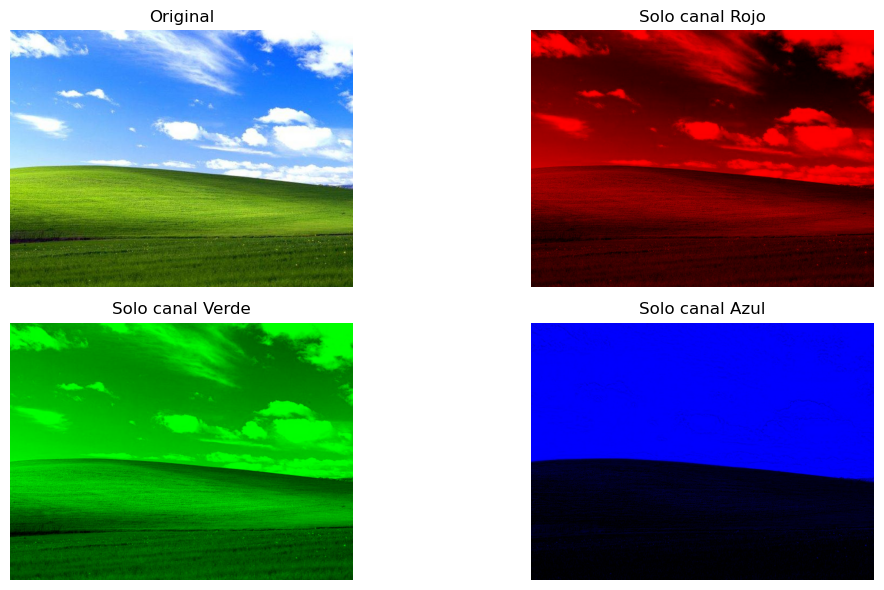

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Nombre de la imagen de entrada
nombreA = "imagen.jpg" 

# 1) Cargar imagen
imagen = cv2.imread(nombreA, cv2.IMREAD_UNCHANGED)
if imagen is None:
    raise FileNotFoundError(f"No se pudo cargar la imagen: {nombreA}")

alto, ancho = imagen.shape[:2]
bandas = 1 if imagen.ndim == 2 else imagen.shape[2]
print(f"Dimensiones: {alto}x{ancho}, Bandas: {bandas}")

# 2) Crear imagen solo con canal Rojo
rojo = np.zeros_like(imagen)
rojo[:, :, 2] = imagen[:, :, 2]  # Canal 2 es Rojo en OpenCV (BGR)

# 3) (Opcional) Crear imágenes para cada canal
azul = np.zeros_like(imagen)
azul[:, :, 0] = imagen[:, :, 0]  # Canal Azul

verde = np.zeros_like(imagen)
verde[:, :, 1] = imagen[:, :, 1]  # Canal Verde

# 4) Mostrar imágenes
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(cv2.cvtColor(rojo, cv2.COLOR_BGR2RGB))
plt.title("Solo canal Rojo")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(cv2.cvtColor(verde, cv2.COLOR_BGR2RGB))
plt.title("Solo canal Verde")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(cv2.cvtColor(azul, cv2.COLOR_BGR2RGB))
plt.title("Solo canal Azul")
plt.axis("off")

plt.tight_layout()
plt.show()

Este código realiza una descomposición de canales de color, separando una imagen original en sus componentes básicos: Rojo, Verde y Azul. 

La clave del proceso reside en cómo OpenCV interpreta las imágenes; a diferencia del estándar común, utiliza el formato BGR (Azul, Verde, Rojo). El script crea tres copias de la imagen original rellenas de negro y, mediante la manipulación de matrices, extrae y asigna cada color individualmente a su respectivo canal (índice 0 para azul, 1 para verde y 2 para rojo).

El código utiliza Matplotlib para mostrar una cuadrícula comparativa y emplea cv2.cvtColor para transformar los datos de BGR a RGB, asegurando que los colores se visualicen correctamente en pantalla.

### EJERCICIO 7. CARGAR VÍDEO Y MANIPULARLO
Escriba un programa en Python que cargue un vídeo y lo muestre en pantalla con vuestro nombre superpuesto en la esquina superior derecha

In [1]:
import cv2
import os

# Ruta del vídeo
video_path = "video.mp4"

cap = cv2.VideoCapture(video_path)

nombre = "Juan Manuel Mena Hernandez"

# Comprobar si video se reproduce correctamente
if not cap.isOpened():
    print (" Error : No se pudo leer el video.")
else :
    print (" Presiona ’q’ para salir .")
while True :
    # Capturar frame a frame
    ret , frame = cap.read()
    # Si el frame no se capturo bien , saltar
    if not ret:
        break
    
    
    # Obtener dimensiones del frame
    alto, ancho = frame.shape[:2]
    centro_x = ancho // 2
    centro_y = alto // 2
    
    # Dibujar el nombre sobre el frame en esquina superior derecha
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 1.2
    thickness = 2
    color_texto = (0, 255, 255)  # Amarillo en BGR
    
    (text_width, text_height), baseline = cv2.getTextSize(nombre, font, font_scale, thickness)
    x = ancho - text_width - 10
    y = text_height + 10
    
    cv2.putText(frame, nombre, (x, y), font, font_scale, color_texto, thickness, cv2.LINE_AA)
    
    # Mostrar el frame
    cv2.imshow('Video con tu nombre', frame)
    
    # Presionar 'q' para salir
    if cv2.waitKey(30) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

 Presiona ’q’ para salir .


Este código superpone un texto personalizado en tiempo real sobre cada fotograma. Primero, abre el archivo video.mp4, luego entra en un bucle donde lee el vídeo frame a frame y calcula las dimensiones de la imagen con el fin de posicionar el nombre "Juan Manuel Mena Hernandez" exactamente en la esquina superior derecha.

El script utiliza la función cv2.getTextSize, la cual mide el ancho y alto del nombre antes de dibujarlo, permitiendo ajustar las coordenadas según el tamaño de la pantalla.

### EJERCICIO 8. CARGAR V´IDEO Y DIBUJAR GEOMETRÍA DINAMICA
Escriba un programa en Python que cargue un vídeo (o use la cámara web) y lo muestre en pantalla. A diferencia del ejercicio anterior, esta vez debe dibujar un círculo de color rojo en el centro de la imagen.
Además, el radio de dicho círculo no será fijo, sino que deberá cambiar en
cada frame (fotograma) del vídeo, creando un efecto de "latido" (haciéndose más grande y más pequeño cíclicamente o aleatoriamente) mientras se reproduce el vídeo.

In [18]:
import cv2
import numpy as np

# Ruta del vídeo
video_path = "video.mp4"

cap = cv2.VideoCapture(video_path)

# Comprobar si video se reproduce correctamente
if not cap.isOpened():
    print("Error: No se pudo leer el video.")
else:
    print("Presiona 'q' para salir.")
    frame_count = 0
    
    while True:
        # Capturar frame a frame
        ret, frame = cap.read()
        # Si el frame no se capturo bien, saltar
        if not ret:
            break
        
        # Obtener dimensiones del frame
        alto, ancho = frame.shape[:2]
        centro_x = ancho // 2
        centro_y = alto // 2
        
        # ============ EFECTO DE LATIDO ============
        # El radio oscila entre 20 y 80 píxeles
        radio_min = 20
        radio_max = 80
        radio_promedio = (radio_min + radio_max) // 2
        radio_variacion = (radio_max - radio_min) // 2
        
        # Usar la función seno para crear un efecto suave de latido
        fase = (frame_count % 30) / 30 * 2 * np.pi  # Ciclo de 30 frames
        radio = int(radio_promedio + radio_variacion * np.sin(fase))
        
        # Dibujar círculo rojo en el centro con radio variable
        color_circulo = (0, 0, 255)  # Rojo en BGR
        cv2.circle(frame, (centro_x, centro_y), radio, color_circulo, -1)
        
        # Contorno blanco alrededor del círculo
        cv2.circle(frame, (centro_x, centro_y), radio, (255, 255, 255), 2)
        
        # Mostrar el frame
        cv2.imshow('Video con latido', frame)
        
        # Presionar 'q' para salir
        if cv2.waitKey(30) & 0xFF == ord('q'):
            break
        
        frame_count += 1

cap.release()
cv2.destroyAllWindows()

Presiona 'q' para salir.


Este código crea una animación dinámica sobre un vídeo, dibujando un círculo en el centro que parece "latir". Para lograr este efecto, el script utiliza una función matemática de seno que hace oscilar el radio del círculo entre 20 y 80 píxeles. Al vincular el tamaño del radio con el contador de fotogramas (frame_count), el círculo se expande y contrae rítmicamente cada 30 frames, simulando el latido.

En cada iteración del bucle, el programa calcula el centro exacto del vídeo y dibuja dos elementos: un círculo rojo relleno y un contorno blanco. La velocidad de la animación está controlada por el tiempo de espera en cv2.waitKey, permitiendo que el espectador vea el latido en tiempo real mientras el vídeo de fondo continúa su reproducción normal hasta que se presiona la tecla 'q'.